In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.multioutput import MultiOutputRegressor, RegressorChain
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, MultiTaskLasso, MultiTaskElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import f_regression, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import holidays
import warnings
warnings.filterwarnings("ignore")
import os


In [18]:
# def validate_file_system():
#     required_files = {
#         'data': 'gb_dcl_prices_gbp_per_mw_per_hour.csv',
#         'notebook': 'forecasting_dcl(con.).ipynb'
#     }
    
#     for ftype, fname in required_files.items():
#         if not os.path.exists(fname):
#             raise FileNotFoundError(f"Critical {ftype} file missing: {fname}")
#     print("All required files present")

In [20]:
# INTERVAL_HOURS = 4
# SAMPLES_PER_DAY = 24 // INTERVAL_HOURS
# FORECAST_WINDOW = 7 * SAMPLES_PER_DAY

In [23]:
four_hourly_metrics = pd.read_csv('../src/data/processed/4hourly_metrics.csv', parse_dates=['4hour_block'])
dcl_prices = pd.read_csv('../src/data/processed/gb_dcl_prices_gbp_per_mw_per_hour.csv', parse_dates=['dtutc'])

dcl_prices['4hour_block'] = dcl_prices['dtutc'].dt.floor('4H')
dcl_prices['time_block'] = dcl_prices['dtutc'].dt.hour // 4 + 1
dcl_grouped = dcl_prices.groupby(['4hour_block', 'time_block'])['dcl_price'].mean().reset_index()
dcl_pivot = dcl_grouped.pivot(index='4hour_block', columns='time_block', values='dcl_price').reset_index()
dcl_pivot.columns = ['4hour_block'] + [f'price_{i}' for i in range(1, 7)]

# Ensuring herse datetime types are consistent
four_hourly_metrics['4hour_block'] = pd.to_datetime(four_hourly_metrics['4hour_block'], utc=True)
dcl_pivot['4hour_block'] = pd.to_datetime(dcl_pivot['4hour_block'], utc=True)

data = pd.merge(four_hourly_metrics, dcl_pivot, on='4hour_block', how='inner')


In [26]:
def add_features(data):
    uk_holidays = holidays.UK()
    data['is_holiday'] = data['4hour_block'].dt.date.apply(lambda x: x in uk_holidays).astype(int)
    
    data['day_of_week'] = data['4hour_block'].dt.dayofweek
    data['season'] = data['4hour_block'].dt.month % 12 // 3 + 1  # Winter=1, Spring=2...
    data['hour'] = data['4hour_block'].dt.hour
    data['hour_block'] = data['hour'] // 4 
    
    for i in range(1, 7):
        data[f'price_{i}_lag_24h'] = data.groupby('hour_block')[f'price_{i}'].shift(6).ffill()
        data[f'price_{i}_lag_4h'] = data.groupby('hour_block')[f'price_{i}'].shift(1).ffill()
    
    data['price_volatility'] = data.groupby('hour_block')['price_1'].transform('std') / data.groupby('hour_block')['price_1'].transform('mean')
    data['high_volatility'] = (data['price_volatility'] > data['price_volatility'].quantile(0.75)).astype(int)
    
    return data

data = add_features(data)


In [27]:
target_cols = [f'price_{i}' for i in range(1, 7)]

X = data.select_dtypes(include='number').drop(columns=target_cols, errors='ignore')
y = data[target_cols]

print(X.dtypes)


demand_National Demand Forecast (NDF) - GB (MW)_mean                                      float64
demand_National Demand Forecast (NDF) - GB (MW)_max                                       float64
demand_National Demand Forecast (NDF) - GB (MW)_min                                       float64
demand_National Demand Forecast (NDF) - GB (MW)_spread                                    float64
demand_National Demand Forecast (NDF) - GB (MW)_std                                       float64
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_mean              float64
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_max               float64
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_min               float64
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_spread            float64
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_std               float64
price_Price average 

In [28]:
train_start_date = pd.Timestamp('2024-03-01', tz='UTC')
train_end_date = pd.Timestamp('2024-08-31', tz='UTC') 
test_start_date = pd.Timestamp('2024-09-01 04:00:00', tz='UTC')
test_end_date = pd.Timestamp('2024-09-30', tz='UTC')

X_train = X[data['4hour_block'] <= train_end_date]
y_train = y[data['4hour_block'] <= train_end_date]
X_test = X[(data['4hour_block'] >= test_start_date) & (data['4hour_block'] <= test_end_date)]
y_test = y[(data['4hour_block'] >= test_start_date) & (data['4hour_block'] <= test_end_date)]

y_train = y_train.fillna(y_train.mean())
y_test = y_test.fillna(y_train.mean())
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())


In [29]:
def univariate_feature_selection(X, y, k=20):
    X = X.loc[:, X.notna().any()]
    
    missing_count = X.isnull().sum().sum()
    if missing_count > 0:
        print(f"Imputing {missing_count} missing values before feature selection")
        imputer = SimpleImputer(strategy='mean')
        X_imputed = imputer.fit_transform(X)
        
        X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)
        
        k = min(k, X_imputed_df.shape[1])
        
        selector = SelectKBest(score_func=f_regression, k=k)
        X_selected = selector.fit_transform(X_imputed_df, y.iloc[:, 0])
        selected_features = X.columns[selector.get_support()]
    else:
        k = min(k, X.shape[1])
        
        selector = SelectKBest(score_func=f_regression, k=k)
        X_selected = selector.fit_transform(X, y.iloc[:, 0])
        selected_features = X.columns[selector.get_support()]
    return X_selected, selected_features

def recursive_feature_elimination(X, y, estimator=LinearRegression(), n_features=20):
    X = X.loc[:, X.notna().any()]
    
    n_features = min(n_features, X.shape[1])
    
    if X.isnull().sum().sum() > 0:
        imputer = SimpleImputer(strategy='mean')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    
    selector = RFE(estimator=estimator, n_features_to_select=n_features)
    X_selected = selector.fit_transform(X, y.iloc[:, 0]) 
    selected_features = X.columns[selector.get_support()]
    return X_selected, selected_features

X_train_selected_uni, selected_features_uni = univariate_feature_selection(X_train, y_train)
X_train_selected_rfe, selected_features_rfe = recursive_feature_elimination(X_train, y_train)

print("Selected features (Univariate):", selected_features_uni)
print("Selected features (RFE):", selected_features_rfe)

X_train_selected = X_train[selected_features_uni]
X_test_selected = X_test[selected_features_uni]


Selected features (Univariate): Index(['demand_National Demand Forecast (NDF) - GB (MW)_mean',
       'demand_National Demand Forecast (NDF) - GB (MW)_max',
       'demand_National Demand Forecast (NDF) - GB (MW)_min',
       'demand_National Demand Forecast (NDF) - GB (MW)_spread',
       'demand_National Demand Forecast (NDF) - GB (MW)_std',
       'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_mean',
       'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_max',
       'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_min',
       'day_of_week', 'is_weekend', 'season', 'price_1_lag_24h',
       'price_1_lag_4h', 'price_2_lag_24h', 'price_3_lag_24h',
       'price_3_lag_4h', 'price_5_lag_24h', 'price_5_lag_4h',
       'price_6_lag_24h', 'price_6_lag_4h'],
      dtype='object')
Selected features (RFE): Index(['price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_mean',
       'price_Price averag

In [30]:
def evaluate_model_internal(pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred, multioutput='raw_values'))
    return rmse

def rolling_window_evaluation(X_train, y_train, model, window_size=24, horizon=6):
   
    X_train_array = X_train.values if hasattr(X_train, 'values') else X_train
    y_train_array = y_train.values if hasattr(y_train, 'values') else y_train
    
    n_samples = len(X_train_array)
    if n_samples <= window_size + horizon:
        return np.nan
    
    errors = []
    for i in range(0, n_samples - window_size - horizon, horizon):
        X_window = X_train_array[i:i+window_size]
        y_window = y_train_array[i:i+window_size]
        
        X_horizon = X_train_array[i+window_size:i+window_size+horizon]
        y_horizon = y_train_array[i+window_size:i+window_size+horizon]
        
        model_clone = clone(model)
        
        model_clone.fit(X_window, y_window)
        y_pred = model_clone.predict(X_horizon)
        
        mse = mean_squared_error(y_horizon, y_pred)
        errors.append(np.sqrt(mse))
    
    return np.mean(errors) if errors else np.nan

def evaluate_all_models(X_train, y_train, X_test, y_test, models):
    results = []
    for name, model in models:
        try:
            if not isinstance(model, (MultiTaskLasso, MultiTaskElasticNet, RegressorChain)):
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('model', MultiOutputRegressor(model))
                ])
            else:
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('model', model)
                ])
            
            rmse = evaluate_model_internal(pipeline, X_train, y_train, X_test, y_test)
            total_rmse = np.sum(rmse)
            
            try:
                rolling_rmse = rolling_window_evaluation(X_train, y_train, pipeline)
            except Exception as e:
                print(f"Rolling window error for {name}: {str(e)}")
                rolling_rmse = np.nan
            
            results.append({
                'Model': name,
                'RMSE': rmse.tolist(),
                'Total_RMSE': total_rmse,
                'Rolling_RMSE': rolling_rmse
            })
            print(f"Evaluated {name}: Total RMSE = {total_rmse:.4f}")
        except Exception as e:
            print(f"Error evaluating {name}: {str(e)}")
    
    return results

def analyze_feature_importance(model, X_train, feature_names):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'named_steps') and hasattr(model.named_steps['model'], 'estimators_'):
        importances = np.mean([est.feature_importances_ for est in model.named_steps['model'].estimators_], axis=0)
    elif hasattr(model, 'named_steps') and hasattr(model.named_steps['model'].estimator, 'feature_importances_'):
        importances = model.named_steps['model'].estimator.feature_importances_
    else:
        from sklearn.inspection import permutation_importance
        perm_importance = permutation_importance(model, X_train, y_train.iloc[:, 0], n_repeats=20, random_state=42)
        importances = perm_importance.importances_mean
    
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    return feature_importance

def calculate_prediction_intervals(model, X_train, y_train, X_test, n_bootstraps=500, alpha=0.1):
    y_preds = np.zeros((n_bootstraps, X_test.shape[0], y_train.shape[1]))
    
    for i in range(n_bootstraps):
        X_resampled, y_resampled = resample(X_train, y_train)
        
        cloned_model = clone(model)
        cloned_model.fit(X_resampled, y_resampled)
        
        y_preds[i] = cloned_model.predict(X_test)
    
    y_mean = np.mean(y_preds, axis=0)
    
    # percentili (90% interval)
    lower = np.percentile(y_preds, (alpha/2)*100, axis=0)
    upper = np.percentile(y_preds, (1-alpha/2)*100, axis=0)
    
    return y_mean, lower, upper


In [32]:
# definiram modeli za evaluacija tuka
models = [
    ('Random Forest', RandomForestRegressor(random_state=42)),
    ('XGBoost', XGBRegressor(random_state=42)),
    ('KNN', KNeighborsRegressor()),
    ('MultiTaskElasticNet', MultiTaskElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)),
    ('MultiTaskLasso', MultiTaskLasso(alpha=0.1, max_iter=10000)),
    ('Ridge Regression', Ridge(alpha=1.0)),
    ('RegressorChain Ridge', RegressorChain(Ridge(alpha=1.0))),
    ('Lasso Regression', Lasso(alpha=0.1)),
    ('ElasticNet', ElasticNet(alpha=0.1, l1_ratio=0.5)),
]

results = evaluate_all_models(X_train_selected, y_train, X_test_selected, y_test, models)

try:
    kmeans_results = pd.read_csv('../src/data/processed/reference_day_performance_dcl.csv')
    euclidean_results = pd.read_csv('../src/data/processed/euclidean_reference_day_performance_dcl.csv')

    kmeans_total_rmse = kmeans_results['rmse'].sum()
    euclidean_total_rmse = euclidean_results['rmse'].sum()

    print(f"K-means Total RMSE: {kmeans_total_rmse:.2f}")
    print(f"Euclidean Total RMSE: {euclidean_total_rmse:.2f}")

    results.append({
        'Model': 'K-means Reference',
        'RMSE': kmeans_results['rmse'].tolist() if 'rmse' in kmeans_results.columns else [],
        'Total_RMSE': kmeans_total_rmse,
        'Rolling_RMSE': float('nan')
    })
    results.append({
        'Model': 'Euclidean Reference',
        'RMSE': euclidean_results['rmse'].tolist() if 'rmse' in euclidean_results.columns else [],
        'Total_RMSE': euclidean_total_rmse,
        'Rolling_RMSE': float('nan')
    })
except Exception as e:
    print(f"Could not load reference day performance: {str(e)}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Total_RMSE')

results_df.to_csv('dcl_price_forecast_results.csv', index=False)

print("Model Evaluation Results:")
print(results_df[['Model', 'Total_RMSE', 'Rolling_RMSE']])


Evaluated Random Forest: Total RMSE = 1.6736
Evaluated XGBoost: Total RMSE = 1.8081
Evaluated KNN: Total RMSE = 1.6706
Evaluated MultiTaskElasticNet: Total RMSE = 1.6109
Evaluated MultiTaskLasso: Total RMSE = 1.6177
Evaluated Ridge Regression: Total RMSE = 1.7342
Evaluated RegressorChain Ridge: Total RMSE = 1.7342
Evaluated Lasso Regression: Total RMSE = 1.6207
Evaluated ElasticNet: Total RMSE = 1.6163
K-means Total RMSE: 85.94
Euclidean Total RMSE: 92.14
Model Evaluation Results:
                   Model  Total_RMSE  Rolling_RMSE
3    MultiTaskElasticNet    1.610909      0.389150
8             ElasticNet    1.616347      0.374647
4         MultiTaskLasso    1.617748      0.358546
7       Lasso Regression    1.620715      0.354850
2                    KNN    1.670618      0.321388
0          Random Forest    1.673611      0.351360
6   RegressorChain Ridge    1.734182      0.661599
5       Ridge Regression    1.734182      0.661599
1                XGBoost    1.808114      0.427788
9   

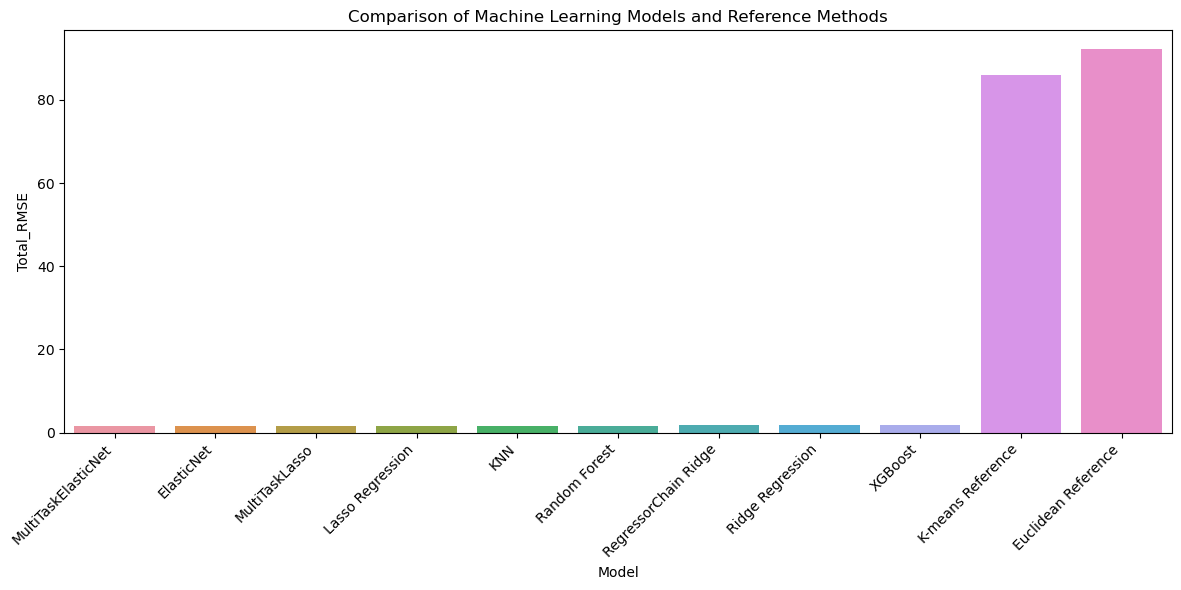

In [35]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Total_RMSE', data=results_df)
plt.xticks(rotation=45, ha='right')
plt.title('Comparison of Machine Learning Models and Reference Methods')
plt.tight_layout()
plt.show()

In [36]:
from sklearn.linear_model import MultiTaskElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

best_model = MultiTaskElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_model)
])

pipeline.fit(X_train_selected, y_train)

y_pred_train = pipeline.predict(X_train_selected)
y_pred_test = pipeline.predict(X_test_selected)


### R², the coefficient of determination, measures how well my model  predictions explain the variability of the actual data 

In [37]:
train_results, train_total_rmse = evaluate_model(y_train, y_pred_train, target_cols)
test_results, test_total_rmse = evaluate_model(y_test, y_pred_test, target_cols)

print("\nTraining Results:")
print(train_results)
print(f"Total RMSE: {train_total_rmse:.4f}")

print("\nTest Results:")
print(test_results)
print(f"Total RMSE: {test_total_rmse:.4f}")



Training Results:
    Output      RMSE        R²
0  price_1  0.191972  0.024651
1  price_2  0.496828  0.026644
2  price_3  0.211224  0.031011
3  price_4  0.375788  0.014621
4  price_5  0.484729  0.055989
5  price_6  0.183779  0.033198
Total RMSE: 0.3508

Test Results:
    Output      RMSE        R²
0  price_1  0.116288  0.017716
1  price_2  0.344332  0.047645
2  price_3  0.087650 -0.017890
3  price_4  0.314651 -0.040056
4  price_5  0.498719  0.006518
5  price_6  0.249268 -0.027319
Total RMSE: 0.3027


In [38]:
model = pipeline.named_steps['model']
coefs = pd.DataFrame(model.coef_, columns=selected_features_uni, index=target_cols)

print("Top features for first output:")
print(coefs.iloc[0].abs().sort_values(ascending=False).head(10))


Top features for first output:
price_5_lag_4h                                                                  0.009711
price_1_lag_4h                                                                  0.009053
demand_National Demand Forecast (NDF) - GB (MW)_mean                            0.003362
season                                                                          0.003276
is_weekend                                                                      0.002221
price_3_lag_4h                                                                  0.000992
price_6_lag_24h                                                                 0.000127
demand_National Demand Forecast (NDF) - GB (MW)_std                             0.000000
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_mean    0.000000
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_max     0.000000
Name: price_1, dtype: float64


In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.iloc[:, 0], 'b-', label='Actual')
plt.plot(y_test.index, y_pred_test[:, 0], 'r-', label='Predicted')
plt.title('DCL Price Forecasting - Time Block 1 (MultiTaskElasticNet)')
plt.xlabel('Date')
plt.ylabel('Price (GBP/MW/h)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [42]:
best_model = RandomForestRegressor(n_estimators=200, random_state=42)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MultiOutputRegressor(best_model))
])

pipeline.fit(X_train_selected, y_train)

y_pred_train = pipeline.predict(X_train_selected)
y_pred_test = pipeline.predict(X_test_selected)

def evaluate_model(y_true, y_pred, output_names=None):
    if output_names is None:
        output_names = [f"Target {i+1}" for i in range(y_true.shape[1])]
    
    mse = mean_squared_error(y_true, y_pred, multioutput='raw_values')
    rmse = np.sqrt(mse)
    
    r2 = []
    for i in range(y_true.shape[1]):
        ss_tot = ((y_true.iloc[:, i] - y_true.iloc[:, i].mean()) ** 2).sum()
        ss_res = ((y_true.iloc[:, i] - y_pred[:, i]) ** 2).sum()
        r2.append(1 - (ss_res / ss_tot))
    
    results = pd.DataFrame({
        'Output': output_names,
        'RMSE': rmse,
        'R²': r2
    })
    
    total_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    return results, total_rmse

train_results, train_total_rmse = evaluate_model(y_train, y_pred_train, target_cols)
test_results, test_total_rmse = evaluate_model(y_test, y_pred_test, target_cols)

print("\nTraining Results:")
print(train_results)
print(f"Total RMSE: {train_total_rmse:.4f}")

print("\nTest Results:")
print(test_results)
print(f"Total RMSE: {test_total_rmse:.4f}")

feature_importance = analyze_feature_importance(pipeline, X_train_selected, selected_features_uni)
print("\nFeature Importance:")
print(feature_importance.head(10))

y_mean, lower, upper = calculate_prediction_intervals(pipeline, X_train_selected, y_train, X_test_selected)

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.iloc[:, 0], 'b-', label='Actual')
plt.plot(y_test.index, y_mean[:, 0], 'r-', label='Predicted')
plt.fill_between(y_test.index, lower[:, 0], upper[:, 0], color='r', alpha=0.2, label='90% Prediction Interval')
plt.title('DCL Price Forecasting - Time Block 1')
plt.xlabel('Date')
plt.ylabel('Price (GBP/MW/h)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('dcl_forecast_tb1.png')
plt.show()



Training Results:
    Output      RMSE        R²
0  price_1  0.071048  0.866407
1  price_2  0.200010  0.842252
2  price_3  0.084001  0.846751
3  price_4  0.145393  0.852495
4  price_5  0.166483  0.888642
5  price_6  0.060904  0.893822
Total RMSE: 0.1321

Test Results:
    Output      RMSE        R²
0  price_1  0.100438  0.267246
1  price_2  0.339536  0.073991
2  price_3  0.103858 -0.429154
3  price_4  0.373740 -0.467361
4  price_5  0.497167  0.012694
5  price_6  0.245188  0.006030
Total RMSE: 0.3118

Feature Importance:
                                              Feature  Importance
3   demand_National Demand Forecast (NDF) - GB (MW...    0.103904
1   demand_National Demand Forecast (NDF) - GB (MW...    0.096063
2   demand_National Demand Forecast (NDF) - GB (MW...    0.081861
4   demand_National Demand Forecast (NDF) - GB (MW...    0.079173
6   price_Price average forecast ECMWF ENS United ...    0.078387
0   demand_National Demand Forecast (NDF) - GB (MW...    0.077277
7   price_P

KeyboardInterrupt: 

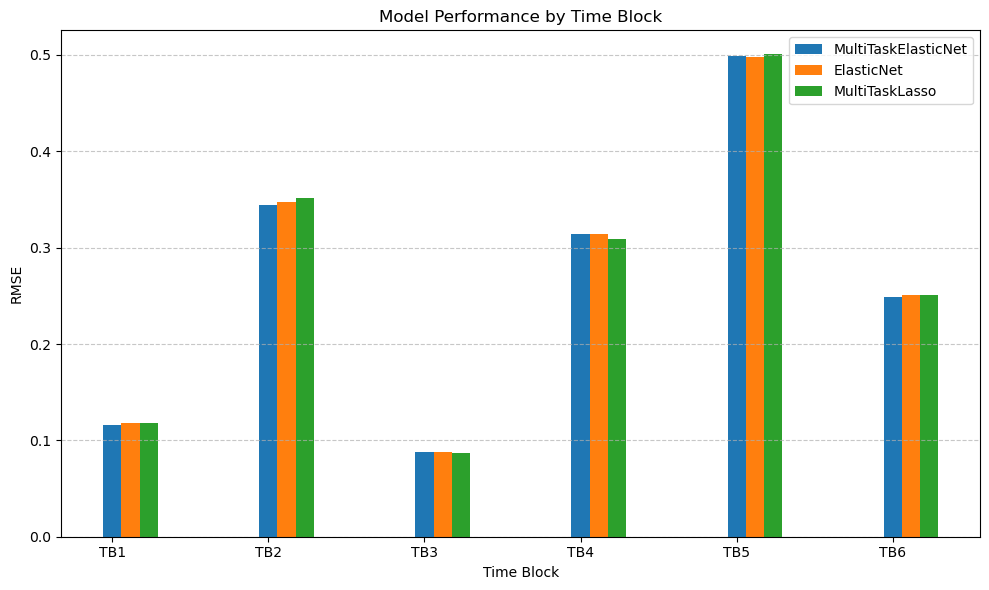

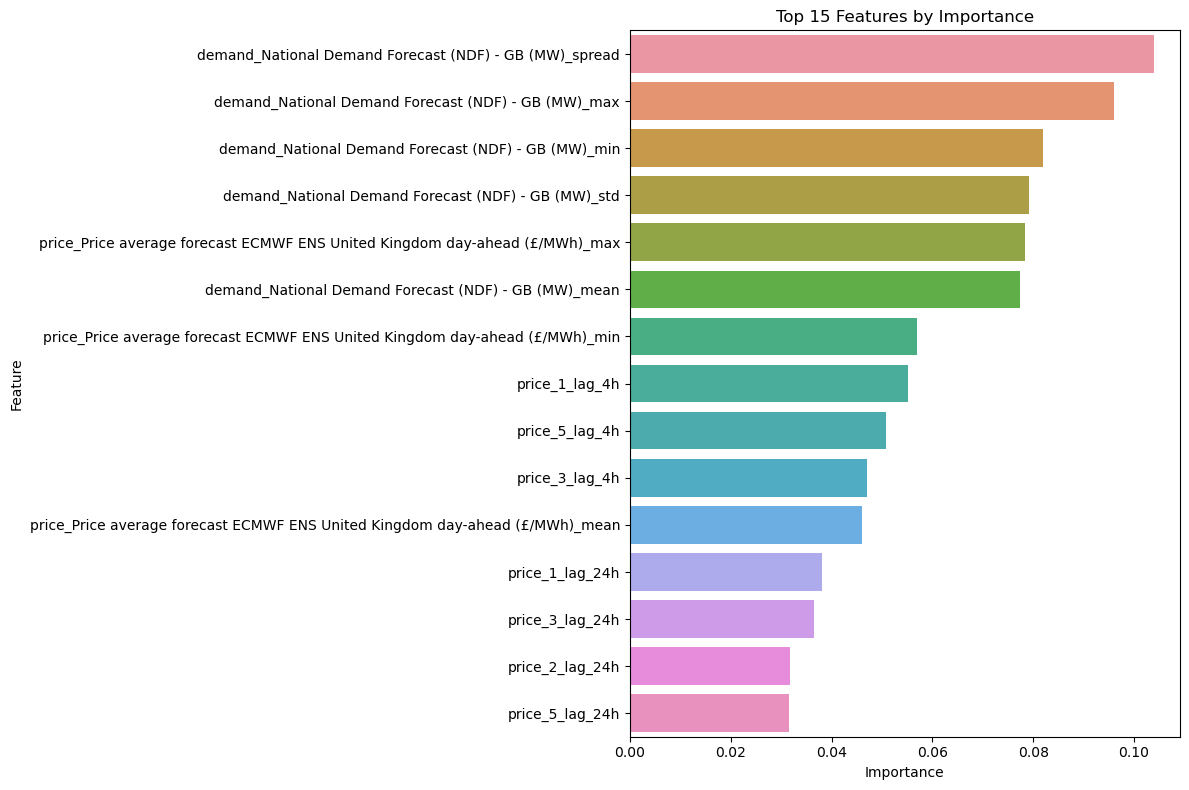

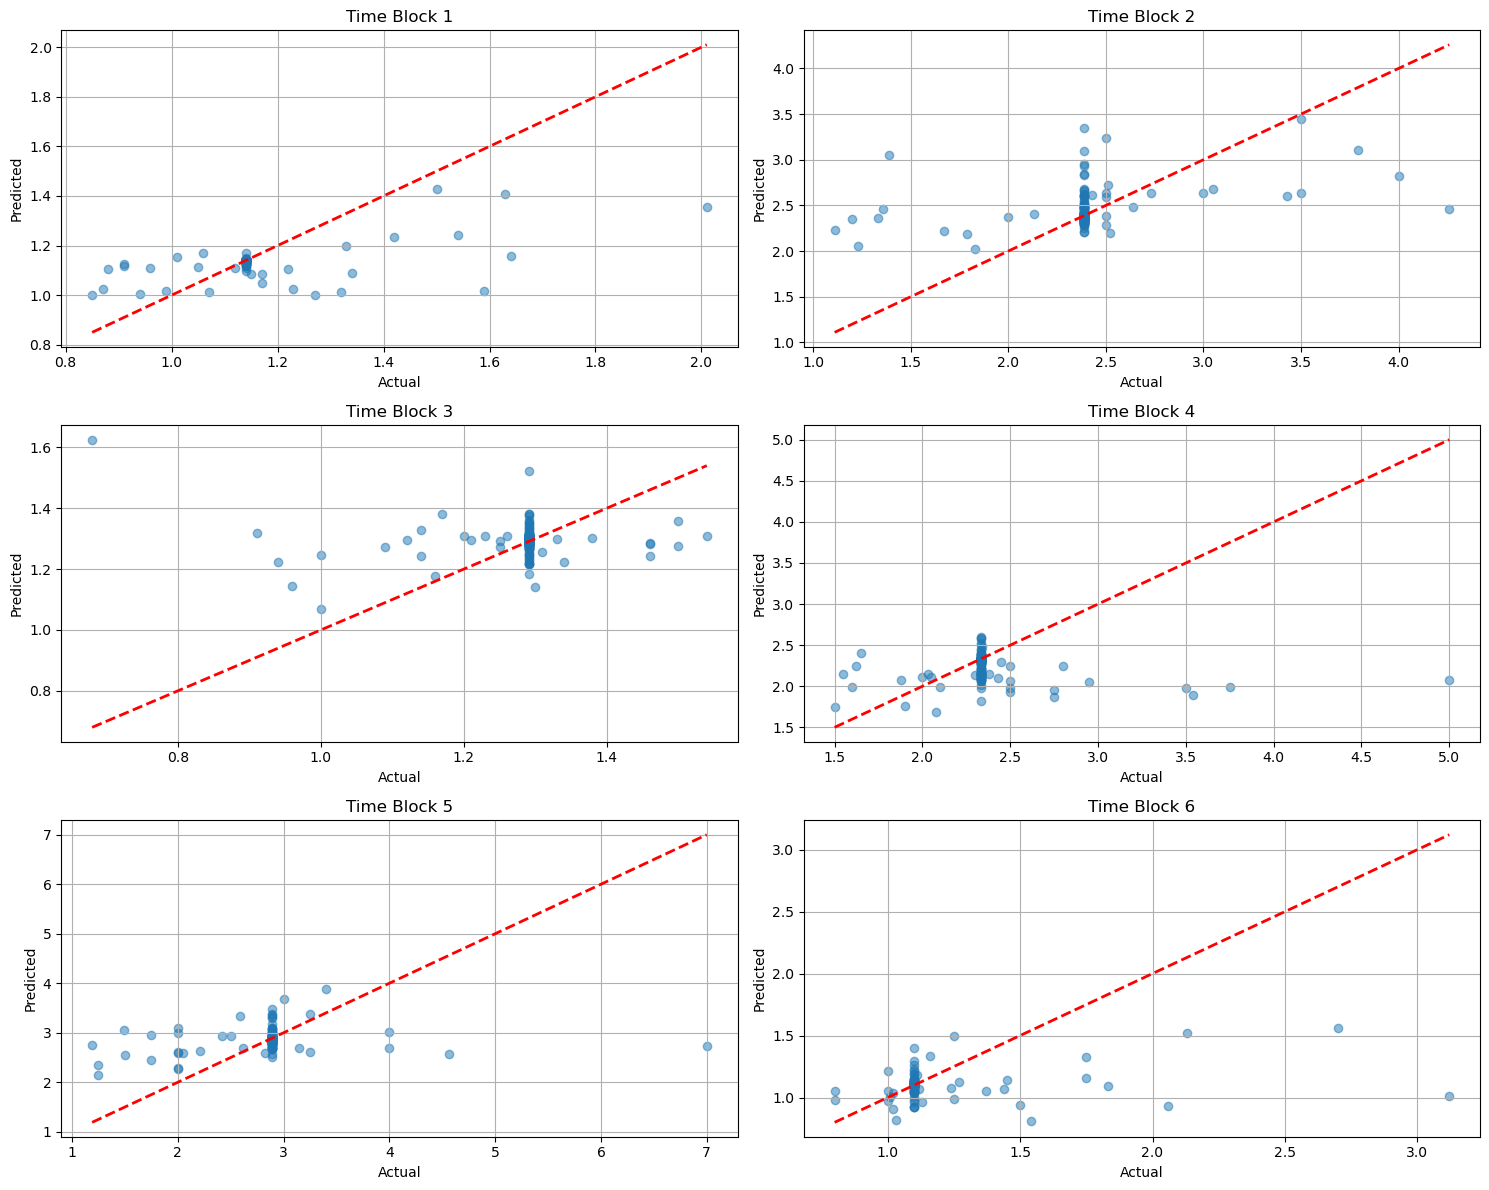

In [43]:
# Ploting RMSE by time block
plt.figure(figsize=(10, 6))
x = np.arange(len(target_cols))
width = 0.35

top_models = results_df.head(3)
for i, row in enumerate(top_models.itertuples()):
    plt.bar(x + i*width/len(top_models), row.RMSE, width/len(top_models), label=row.Model)

plt.xlabel('Time Block')
plt.ylabel('RMSE')
plt.title('Model Performance by Time Block')
plt.xticks(x, [f'TB{i+1}' for i in range(len(target_cols))])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('model_performance_by_timeblock.png')
plt.show()

plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
sns.barplot(x='Importance', y='Feature', data=top_features)
plt.title('Top 15 Features by Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(target_cols):
        ax.scatter(y_test.iloc[:, i], y_pred_test[:, i], alpha=0.5)
        ax.plot([y_test.iloc[:, i].min(), y_test.iloc[:, i].max()], 
                [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()], 
                'r--', lw=2)
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'Time Block {i+1}')
        ax.grid(True)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()


In [44]:
import joblib

joblib.dump(pipeline, 'dcl_forecast_model.pkl')
print("Model saved successfully.")

with open('selected_features.txt', 'w') as f:
    for feature in selected_features_uni:
        f.write(f"{feature}\n")
print("Selected features saved successfully.")


Model saved successfully.
Selected features saved successfully.


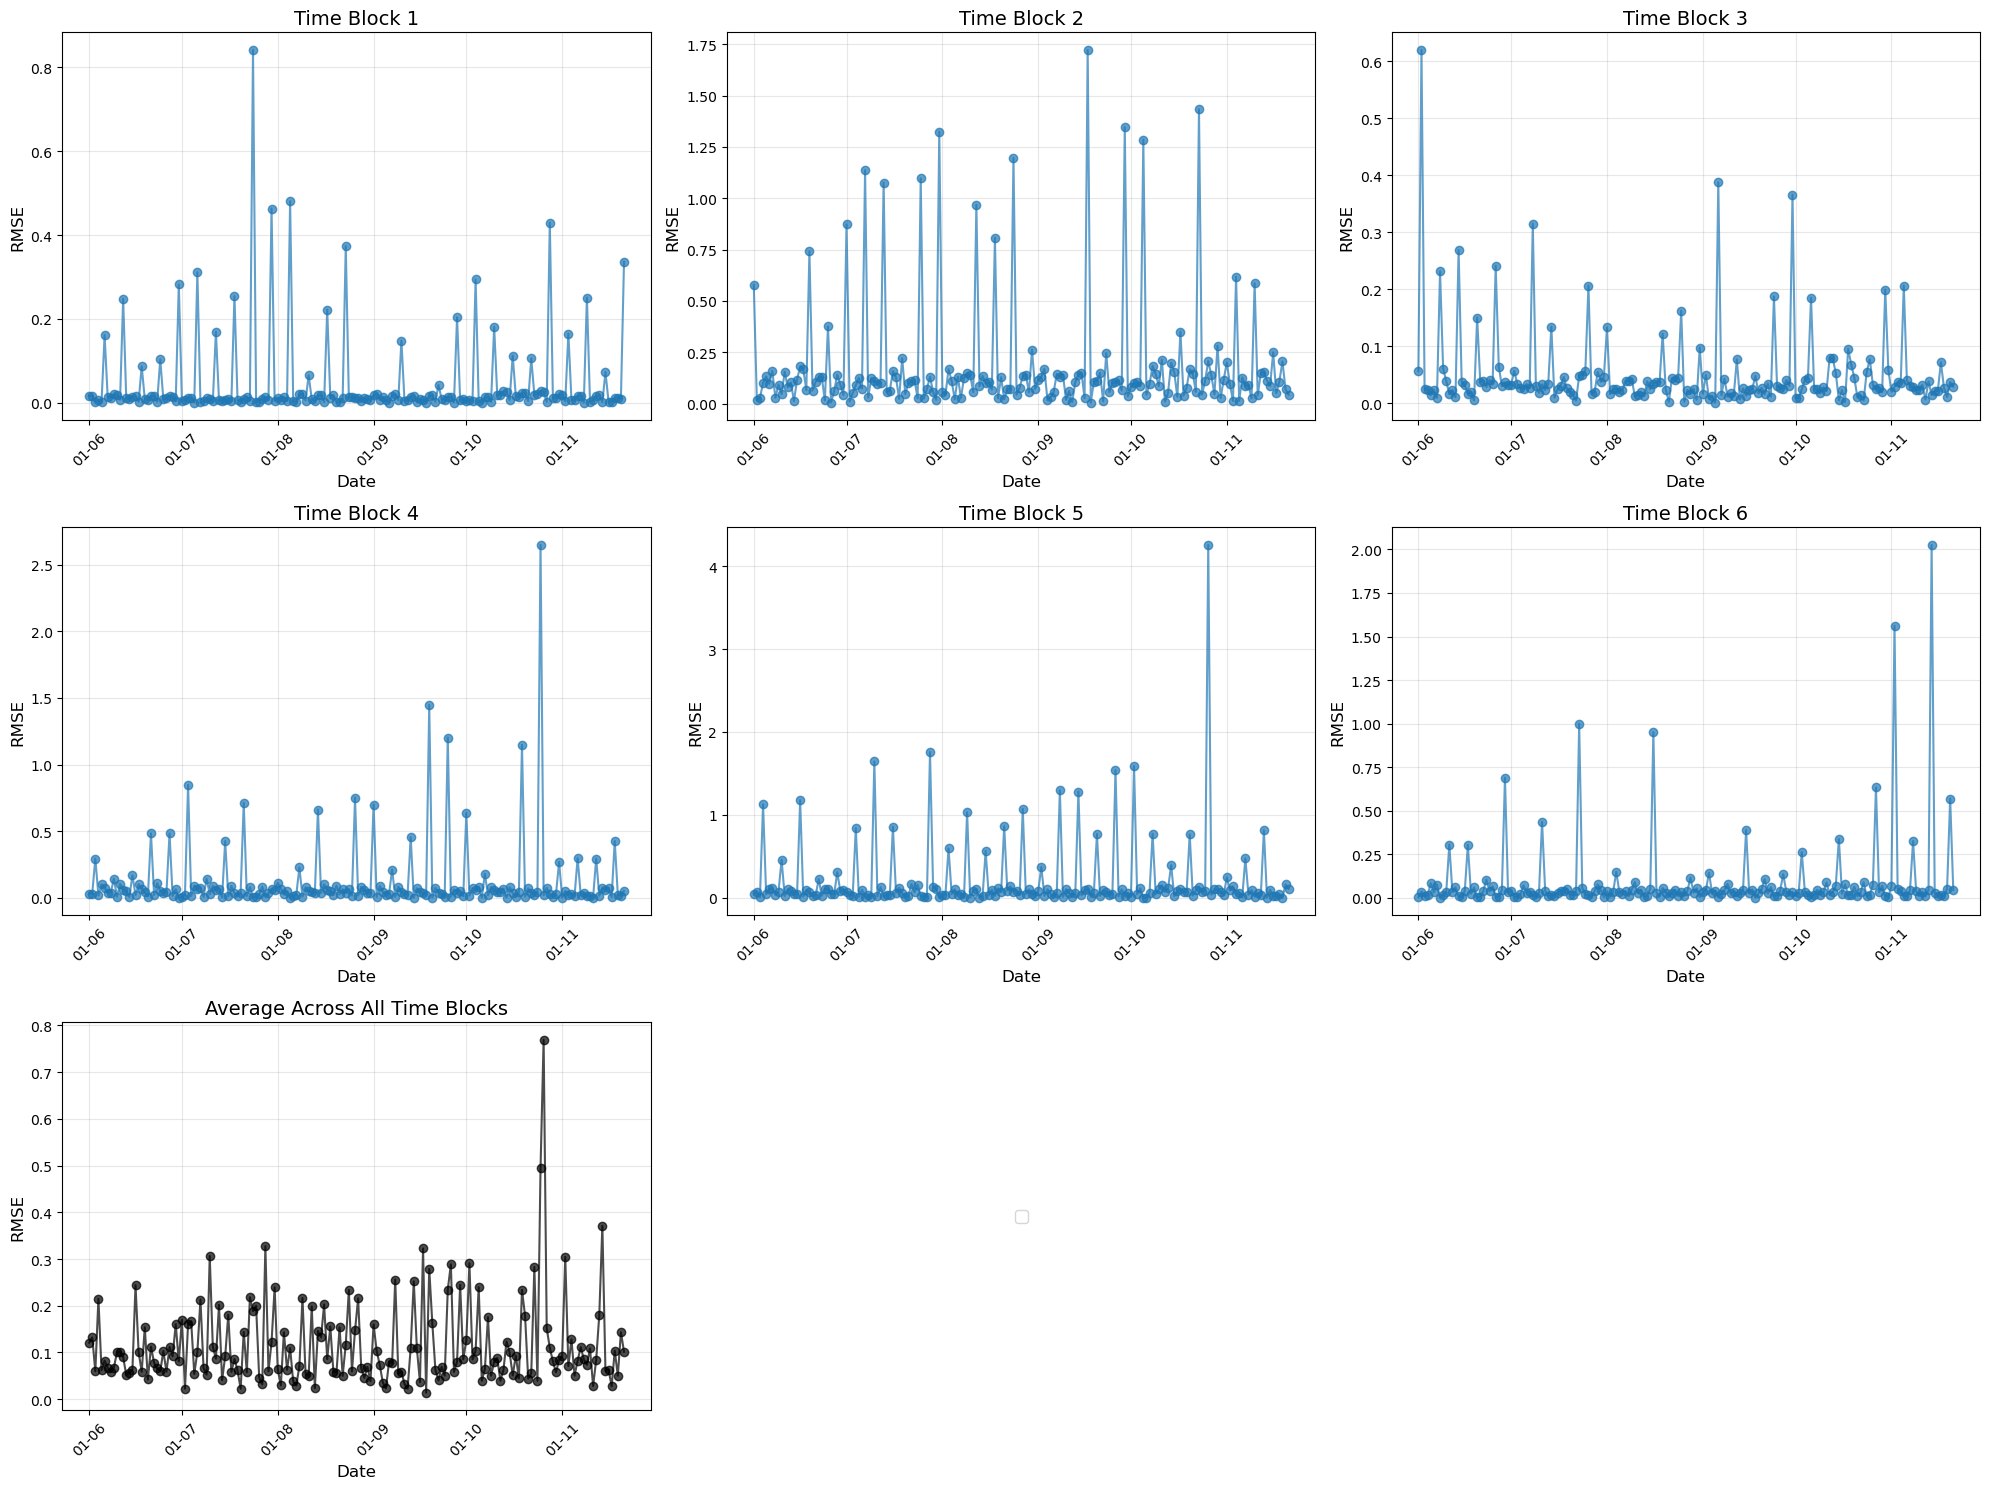

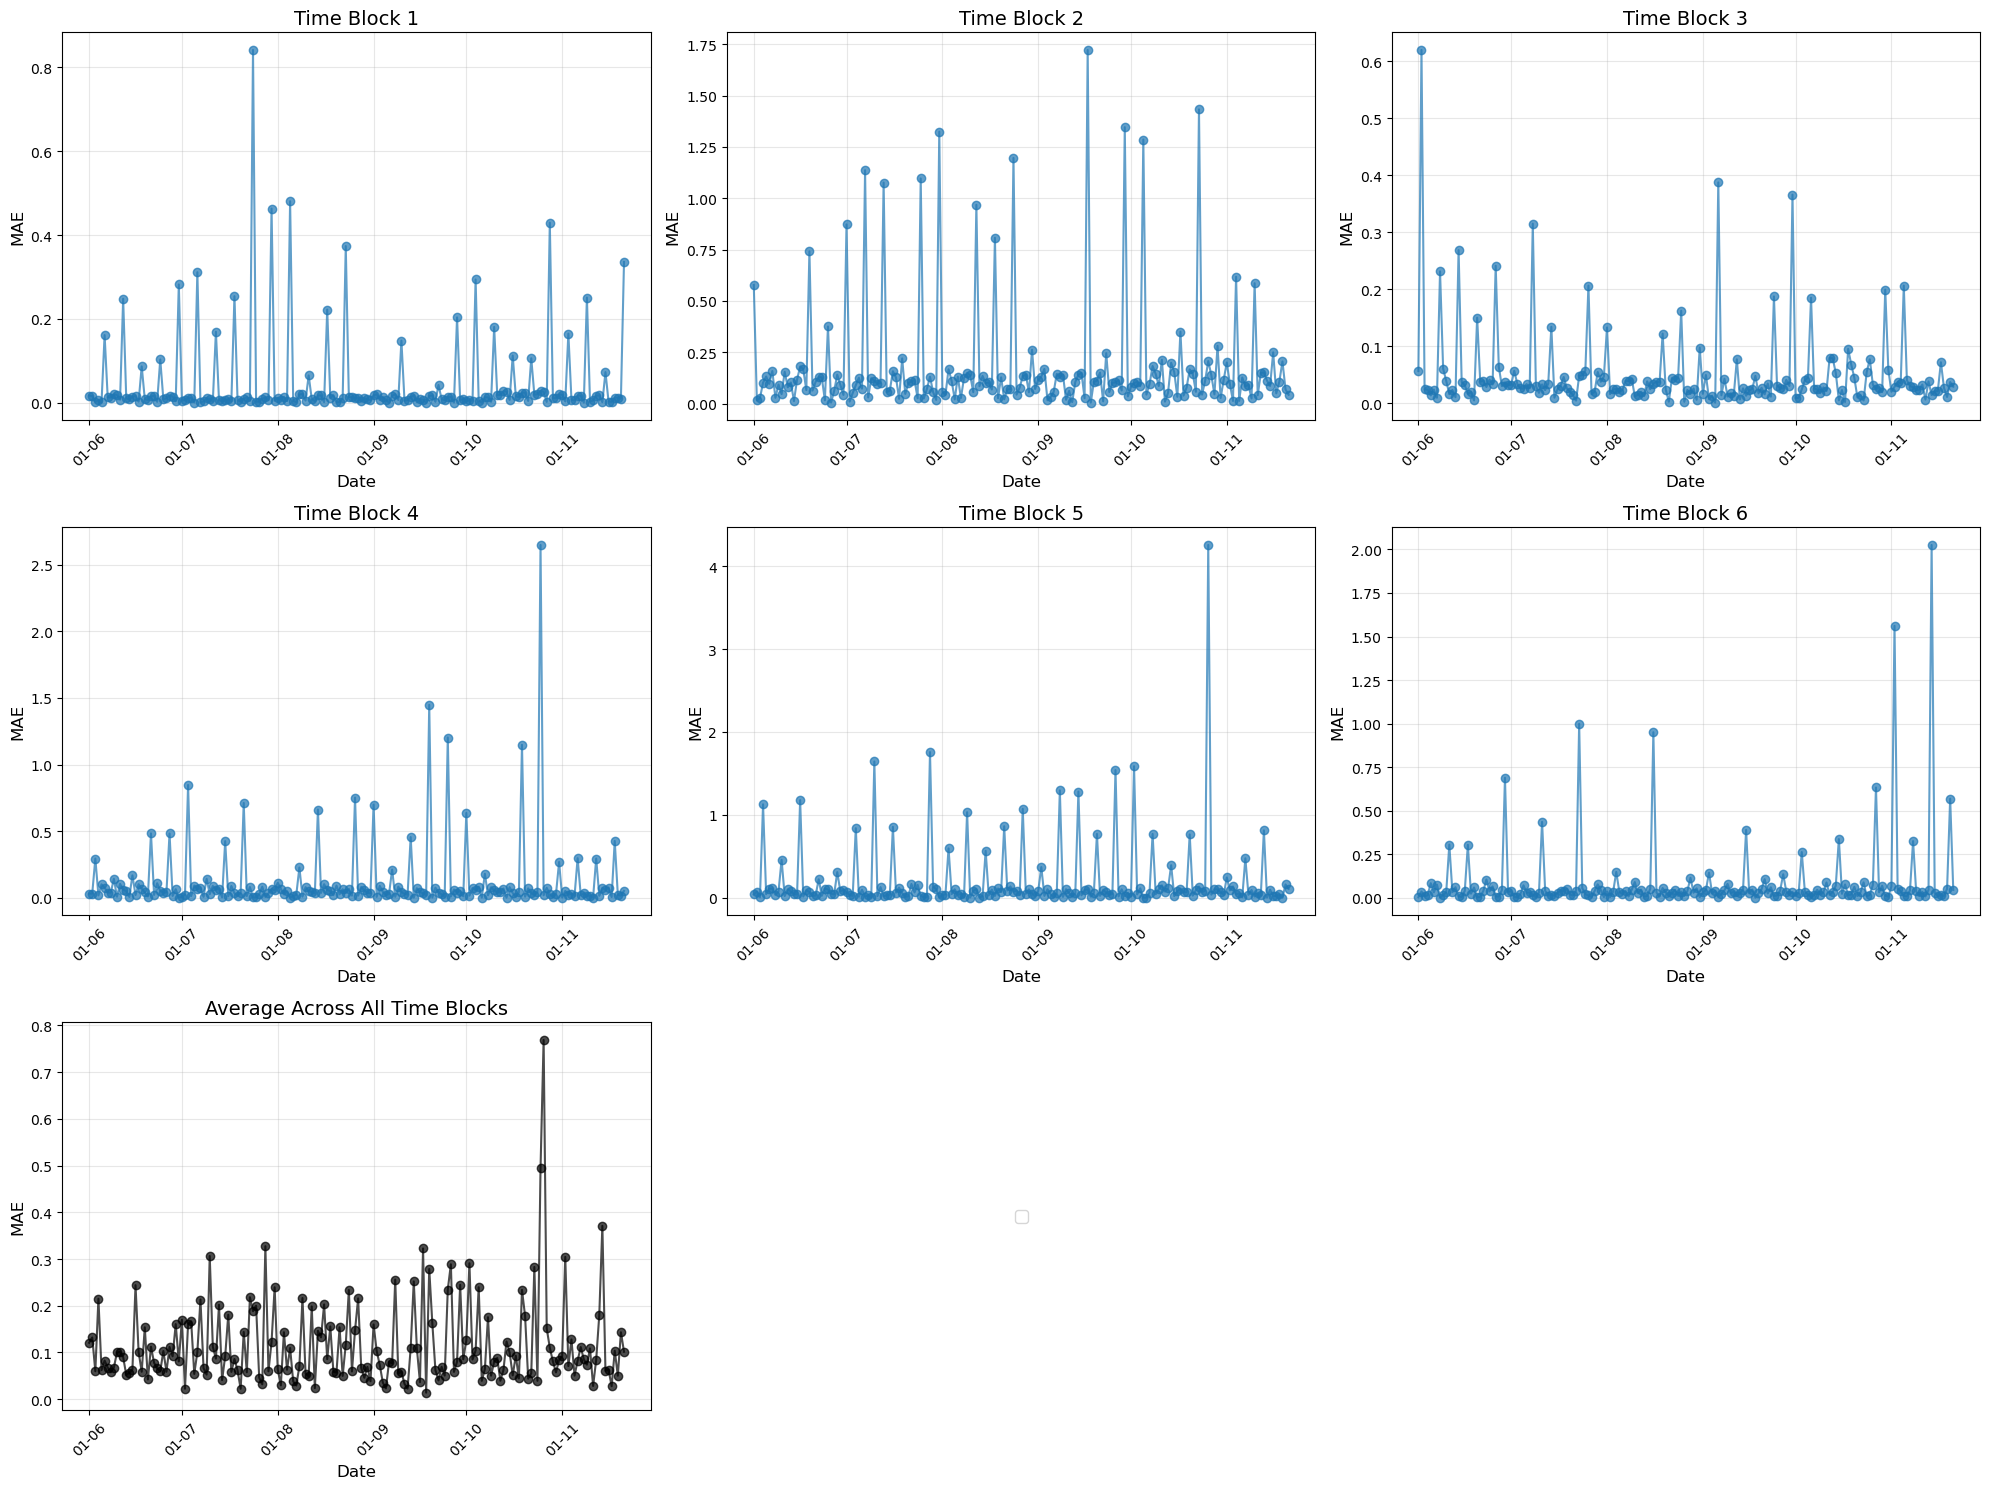

In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import MultiTaskElasticNet
import matplotlib.dates as mdates

def plot_error_metrics_best_model(metric_type='RMSE'):
    fig, axs = plt.subplots(3, 3, figsize=(20, 15))
    axs = axs.flatten()
    
    model_name = 'MultiTaskElasticNet'
    model = MultiTaskElasticNet(random_state=42)
    
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    
    if hasattr(y_test, 'index') and isinstance(y_test.index, pd.DatetimeIndex):
        test_dates = y_test.index
    else:
        test_dates = pd.date_range(start='2024-06-01', periods=len(y_test), freq='D')  # Adjust as needed

    daily_errors = []
    for i in range(len(target_cols)):
        if metric_type == 'RMSE':
            errors = np.sqrt((y_test.iloc[:, i] - y_pred[:, i])**2)
        elif metric_type == 'MAE':
            errors = np.abs(y_test.iloc[:, i] - y_pred[:, i])
        else:
            raise ValueError("Metric must be 'RMSE' or 'MAE'")
        daily_errors.append(errors)
    
    avg_errors = np.mean(daily_errors, axis=0)

    for i in range(min(len(target_cols), 6)):
        ax = axs[i]
        ax.plot(test_dates, daily_errors[i], label=f'TB{i+1}', marker='o', alpha=0.7)
        ax.set_title(f'Time Block {i+1}', fontsize=14)
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel(metric_type, fontsize=12)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)

    axs[6].plot(test_dates, avg_errors, label='Average', color='black', marker='o', alpha=0.7)
    axs[6].set_title('Average Across All Time Blocks', fontsize=14)
    axs[6].set_xlabel('Date', fontsize=12)
    axs[6].set_ylabel(metric_type, fontsize=12)
    axs[6].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
    axs[6].tick_params(axis='x', rotation=45)
    axs[6].grid(True, alpha=0.3)

    axs[7].legend([model_name], loc='center', fontsize=12)
    axs[7].axis('off')
    axs[8].axis('off')

    plt.tight_layout()
    plt.savefig(f'../src/data/processed/plots/{model_name}_{metric_type}_time_series.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_error_metrics_best_model('RMSE')
plot_error_metrics_best_model('MAE')


In [17]:
model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
model.fit(X_train_selected, y_train)


MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42))